### neural network study

这里的“学习”是指从**训练数据中自动获取最优权重参数的过程**。本章中，为了使神经网络能进行学习，将导入**损失函数这一指标**。而学习的目的就是以该损失函数为基准，找出能使它的值达到最小的权重参数。为了找出尽可能小的损失函数的值，本章我们将介绍利用了函数斜率的梯度法。

#### 从数据中学习
神经网络的特征就是可以从数据中学习。所谓“从数据中学习”，是指可以**由数据自动决定权重参数的值**。这是非常了不起的事情！因为如果所有的参数都需要人工决定的话，工作量就太大了。在第2章介绍的感知机的例子中，我们对照着真值表，人工设定了参数的值，但是那时的参数只有3个。而在实际的神经网络中，**参数的数量成千上万**，在层数更深的深度学习中，参数的数量甚至可以上亿，想要人工决定这些参数的值是不可能的。本章将介绍神经网络的学习，即利用数据决定参数值的方法，并用Python实现对MNIST手写数字数据集的学习。
> 对于线性可分问题，第2章的感知机是可以利用数据自动学习的。根据“感知机收敛定理”，通过有限次数的学习，线性可分问题是可解的。但是，非线性可分问题则无法通过（自动）学习来解决。

##### 数据驱动
机器学习的方法则极力避免人为介入，尝试从收集到的数据中发现答案（模式）。神经网络或深度学习则比以往的机器学习方法更能避免人为介入。
现在我们来思考一个具体的问题，比如如何实现数字“5”的识别。数字5是图4-1所示的手写图像，我们的目标是实现能区别是否是5的程序。这个问题看起来很简单，大家能想到什么样的算法呢？

<img src="data/neural_study/image1.png" style="width:50%;">

如果让我们自己来设计一个能将5正确分类的程序，就会意外地发现这是一个很难的问题。人可以简单地识别出5，但却很难明确说出是基于何种规律而识别出了5。此外，从图4-1中也可以看到，每个人都有不同的写字习惯，要发现其中的规律是一件非常难的工作。<br>
因此，与其绞尽脑汁，从零开始想出一个可以识别5的算法，不如考虑**通过有效利用数据来解决**这个问题。一种方案是，先从图像中**提取特征量**，再用机器学习技术学习这些特征量的模式。这里所说的“特征量”是指可以从输入数据（输入图像）中准确地提取本质数据（重要的数据）的转换器。图像的特征量通常表示为向量的形式。在计算机视觉领域，常用的特征量包括 SIFT、SURF 和 HOG 等。使用这些特征量将图像数据转换为向量，然后对转换后的向量使用机器学习中的SVM、KNN等分类器进行学习。<br>
机器学习的方法中，由机器从收集到的数据中找出规律性。与从零开始想出算法相比，这种方法可以更高效地解决问题，也能减轻人的负担。但是需要注意的是，**将图像转换为向量时使用的特征量仍是由人设计的**。对于不同的问题，必须使用合适的特征量（必须设计专门的特征量），才能得到好的结果。比如，为了区分狗的脸部，人们需要考虑与用于识别5的特征量不同的其他特征量。也就是说，即使使用特征量和机器学习的方法，也需要针对不同的问题人工考虑合适的特征量。<br>
到这里，我们介绍了两种针对机器学习任务的方法。将这两种方法用图来表示，如图4-2所示。图中还展示了神经网络（深度学习）的方法，可以看出该方法不存在人为介入。<br>
如图4-2所示，神经网络直接学习图像本身。在第2个方法，即利用特征量和机器学习的方法中，特征量仍是由人工设计的，而在神经网络中，连 图像中包含的重要特征量也都是由机器来学习的。

<img src="data/neural_study/image2.png" style="width:50%;">

> 深度学习有时也称为端到端机器学习（end-to-end machine learning）。这里所说的端到端是指从一端到另一端的意思，也就是从原始数据（输入）中获得目标结果（输出）的意思。

神经网络的优点是**对所有的问题都可以用同样的流程来解决**。比如，不管要求解的问题是识别5，还是识别狗，抑或是识别人脸，神经网络都是通过不断地学习所提供的数据，尝试发现待求解的问题的模式。也就是说，与待处理的问题无关，**神经网络可以将数据直接作为原始数据，进行“端对端”的学习**。

##### 训练数据和测试数据
本章主要介绍神经网络的学习，不过在这之前，我们先来介绍一下机器 学习中有关数据处理的一些注意事项。<br>
机器学习中，一般将数据分为**训练数据和测试数据**两部分来进行学习和实验等。首先，使用训练数据进行学习，寻找最优的参数；然后，使用测试数据评价训练得到的模型的实际能力。为什么需要将数据分为训练数据和测试数据呢？因为我们追求的是**模型的泛化能力**。为了正确评价模型的泛化能力，就必须划分训练数据和测试数据。另外，训练数据也可以称为监督数据。<br>
泛化能力是指处理未被观察过的数据（不包含在训练数据中的数据）的能力。**获得泛化能力是机器学习的最终目标**。比如，在识别手写数字的问题中，泛化能力可能会被用在自动读取明信片的邮政编码的系统上。此时，手写数字识别就必须具备较高的识别“某个人”写的字的能力。注意这里不是“特定的某个人写的特定的文字”，而是“任意一个人写的任意文字”。如果系统只能正确识别已有的训练数据，那有可能是只学习到了训练数据中的个人的习惯写法。<br>
因此，仅仅用一个数据集去学习和评价参数，是无法进行正确评价的。这样会导致可以顺利地处理某个数据集，但无法处理其他数据集的情况。顺便说一下，只对某个数据集**过度拟合的状态称为过拟合**（over fitting）。避免过拟合也是机器学习的一个重要课题。

#### 损失函数
神经网络的学习通过某个指标表示现在的状态。然后，以这个指标为基准，寻找最优权重参数。<br>
神经网络以某个指标为线索寻找最优权重参数。神经网络的学习中所用的**指标称为损失函数**（loss function）。这个损失函数可以使用任意函数， 但一般用均方误差和交叉熵误差等。
> 损失函数是表示神经网络性能的“恶劣程度”的指标，即当前的神经网络对监督数据在多大程度上不拟合，在多大程度上不一致。以“性能的恶劣程度”为指标可能会使人感到不太自然，但是如果给损失函数乘上一个负值，就可以解释为“在多大程度上不坏”，即“性能有多好”。并且，“使性能的恶劣程度达到最小”和“使性能的优良程度达到最大”是等价的，不管是用“恶劣程度”还是“优良程度”，做的事情本质上都是一样的。

##### 均方误差
可以用作损失函数的函数有很多，其中最有名的是均方误差（mean squared error）。均方误差如下式所示。

$ E = \frac{1}{2} \sum_{k}(y_{k}-t_{k})^{2}\qquad\qquad\qquad\qquad \qquad \rm(4.1) $

这里，$y_k$是表示神经网络的输出，$t_k$表示监督数据，k表示数据的维数。<br>

比如，在3.6节手写数字识别的例子中，$ y_k、t_k $是由如下10个元素构成的数据。<br>
 y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0] <br>
 t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0] <br>
数组元素的索引从第一个开始依次对应数字“0”“1”“2”……这里，神经网络的输出y是softmax函数的输出。由于softmax函数的输出可以理解为概率，因此上例表示“0”的概率是0.1，“1”的概率是0.05，“2”的概率是0.6等。t是监督数据，将正确解标签设为1，其他均设为0。这里，标签“2”为1，表示正确解是“2”。将正确解标签表示为1，其他标签表示为0的表示方法**称为one-hot表示**。<br>
如式（4.1）所示，均方误差会计算神经网络的输出和正确解监督数据的各个元素之差的平方，再求总和。现在，我们用Python来实现这个均方误差，实现方式如下所示。

In [3]:
import numpy as np
def mean_squared_error(y, t):
    return 0.5 * np.sum((y - t)**2)

# 设“2”为正确解 
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
# 例1：“2”的概率最高的情况（0.6） 
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]
print(mean_squared_error(np.array(y), np.array(t))) # 0.097500000000000031 
# 例2：“7”的概率最高的情况（0.6）
y = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]    
print(mean_squared_error(np.array(y), np.array(t))) # 0.59750000000000003

0.09750000000000003
0.5975


这里举了两个例子。第一个例子中，正确解是“2”，神经网络的输出的最大值是“2”；第二个例子中，正确解是“2”，神经网络的输出的最大值是“7”。如实验结果所示，我们发现第一个例子的损失函数的值更小，和监督数据之间的误差较小。也就是说，均方误差显示第一个例子的输出结果与监督数据更加吻合。

##### 交叉熵误差
除了均方误差之外，交叉熵误差（cross entropy error）也经常被用作损失函数。交叉熵误差如下式所示。

$ E = -\sum_{k}t_{k}\log y_{k}\qquad\qquad\qquad\qquad\qquad (4.2) $ 

这里，log表示以e为底数的自然对数（$\log \tiny{\mathrm{e}}$）。$y_k$是神经网络的输出，$t_k$ 是正确解标签。并且，$t_k$中只有正确解标签的索引为1，其他均为0（one-hot表示）。 因此，式（4.2）实际上只计算对应正确解标签的输出的自然对数。比如，假设正确解标签的索引是“2”，与之对应的神经网络的输出是0.6，则交叉熵误差是 $ −log_{0.6} = 0.51 $；若“2”对应的输出是0.1，则交叉熵误差为 $ −log_{0.1} = 2.30 $。也就是说，交叉熵误差的值是**由正确解标签所对应的输出结果决定的**。<br>

自然对数的图像如图4-3所示。<br>
<img src="data/neural_study/image3.png" style="width:50%;">

如图4-3所示，x等于1时，y为0；随着x向0靠近，y逐渐变小。因此，正确解标签对应的输出越大，式（4.2）的值越接近0；当输出为1时，交叉熵误差为0。此外，如果正确解标签对应的输出较小，则式（4.2）的值较大。<br>

下面，我们来用代码实现交叉熵误差。

In [4]:
def cross_entropy_error(y, t):
    delta = 1e-7
    return -np.sum(t * np.log(y + delta))

t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]
# y1 = np.array([0.1,0.05,0.6,0,0.05,0.1,0,0.1,0,0])
# y1.shape
print(cross_entropy_error(np.array(y), np.array(t))) # 0.51082545709933802




y = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]
print(cross_entropy_error(np.array(y), np.array(t))) # 2.3025840929945458

0.510825457099338
2.302584092994546


这里，参数y和t是NumPy数组。函数内部在计算np.log时，加上了一个微小值delta。这是因为，当出现np.log(0)时，np.log(0)会变为负无限大的-inf，这样一来就会导致后续计算无法进行。作为保护性对策，**添加一个微小值可以防止负无限大的发生**。下面，我们使用cross_entropy_error(y, t)进行一些简单的计算。<br>
第一个例子中，正确解标签对应的输出为0.6，此时的交叉熵误差大约为0.51。第二个例子中，正确解标签对应的输出为0.1的低值，此时的交叉熵误差大约为2.3。由此可以看出，这些结果与我们前面讨论的内容是一致的。 

##### mini-batch学习
机器学习使用训练数据进行学习。使用训练数据进行学习，严格来说，就是针对训练数据计算损失函数的值，找出使该值尽可能小的参数。因此，计算损失函数时必须将所有的训练数据作为对象。也就是说，如果训练数据有100个的话，我们就要把这100个损失函数的总和作为学习的指标。<br>
前面介绍的损失函数的例子中考虑的都是针对单个数据的损失函数。如果要求所有训练数据的损失函数的总和，以交叉熵误差为例，可以写成下面的式（4.3）<br>

$ E=-\frac{1}{N}\sum_{n}\sum_{k}t_{nk}\log y_{nk}\hskip 72.27pt \rm(4.3) $

这里,假设数据有N个，$t_{nk}$表示第n个数据的第k个元素的值（$y_{nk}$是神经网络的输出，$t_{nk}$是监督数据）。式子虽然看起来有一些复杂，其实只是把求单个数据的损失函数的式（4.2）扩大到了N份数据，不过最后还要**除以N进行正规化**。通过除以N，可以求单个数据的“平均损失函数”。通过这样的平均化，可以获得和训练数据的数量无关的统一指标。比如，即便训练数据有1000个或10000个，也可以求得单个数据的平均损失函数。<br>
另外，MNIST数据集的训练数据有60000个，如果以全部数据为对象求损失函数的和，则计算过程需要花费较长的时间。再者，如果遇到大数据，数据量会有几百万、几千万之多，这种情况下以全部数据为对象计算损失函数是不现实的。因此，我们从全部数据中选出一部分，作为全部数据的“近似”。神经网络的学习也是**从训练数据中选出一批数据**（称为mini-batch,小批量），然后对每个mini-batch进行学习。比如，从60000个训练数据中随机选择100笔，再用这100笔数据进行学习。这种学习方式称为mini-batch学习。<br>
下面我们来编写从训练数据中随机选择指定个数的数据的代码，以进行mini-batch学习。在这之前，先来看一下用于读入MNIST数据集的代码。

In [5]:
from dataset.mnist import load_mnist

(x_train, t_train), (x_text, y_text) = \
    load_mnist(normalize=True, one_hot_label=True)

print(x_train.shape)
print(t_train.shape)

(60000, 784)
(60000, 10)


通过设定参数one_hot_label=True，可以得到one-hot表示（即仅正确解标签为1，其余为0的数据结构）<br>
如何从这个训练数据中随机抽取10笔数据呢？我们可以使用NumPy的np.random.choice()，写成如下形式。

In [6]:
train_size = x_train.shape[0]
batch_size = 10
batch_mark = np.random.choice(train_size, batch_size)
x_batch = x_train[batch_mark]
t_batch = t_train[batch_mark]

使用np.random.choice()可以从指定的数字中随机选择想要的数字。比如，np.random.choice(60000, 10)会从0到59999之间随机选择10个数字。如下 面的实际代码所示，我们可以得到一个包含被选数据的索引的数组。<br>
之后，我们只需指定这些随机选出的索引，取出mini-batch，然后使用这个mini-batch计算损失函数即可。

In [7]:
import numpy as np
np.random.choice(60000, 10)

array([29342, 42820, 54619,  6203, 31836, 48295, 55703,  3689, 32205,
        7455], dtype=int32)

##### mini-batch版交叉熵误差的实现
如何实现对应mini-batch的交叉熵误差呢？只要改良一下之前实现的对应单个数据的交叉熵误差就可以了。这里，我们来实现一个可以**同时处理单个数据和批量数据**（数据作为batch集中输入）两种情况的函数。

In [8]:
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    batch_size = y.shape[0]
    return -np.sum(t * np.log(y + 1e-7)) / batch_size

t = np.array([0,0,1,0,0,0,0,0,0,0])
y1 = np.array([0.1,0.05,0.6,0,0.05,0.1,0,0.1,0,0])
y2 = np.array([0.1,0.05,0.1,0,0.05,0.1,0,0.6,0,0])

y_batch = np.array([y1, y2])
y1.ndim
y_batch.ndim, y_batch.size # 数据的维度和数据的总长度
y_batch.shape[0] # 有多少数据

2

这里，y是神经网络的输出，t是监督数据。y的维度为1时，即求单个数据的交叉熵误差时，需要改变数据的形状。并且，当输入为mini-batch时，要用batch的个数进行正规化，计算单个数据的平均交叉熵误差。<br>
此外，当监督数据是标签形式（**非one-hot表示**，而是像“2”“7”这样的标签）时，交叉熵误差可通过如下代码实现。<br>
> 因为one-hot 只有0和1，所以只有对应标签的训练数据才有用。

In [9]:
def corss_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size 

实现的要点是，由于one-hot表示中t为0的元素的交叉熵误差也为0，因此针对这些元素的计算可以忽略。换言之，如果可以获得神经网络在正确解标签处的输出，就可以计算交叉熵误差。因此，t为one-hot表示时通过t * np.log(y)计算的地方，在t为标签形式时，可用np.log(y[np.arange(batch_size), t])实现相同的处理（为了便于观察，这里省略了微小值1e-7）。<br>
作为参考，简单介绍一下np.log(y[np.arange(batch_size), t])。np.arange(batch_size)会生成一个从0到batch_size-1的数组。比如当batch_size为5时，np.arange(batch_size)会生成一个NumPy数组[0, 1, 2, 3, 4]。因为t中标签是以[2, 7, 0, 9, 4]的形式存储的，所以y[np.arange(batch_size),t]能抽出各个数据的正确解标签对应的神经网络的输出（在这个例子中，y[np.arange(batch_size), t]会生成NumPy数组[y[0,2], y[1,7], y[2,0],
y[3,9], y[4,4]]）。

##### 为何要设定损失函数
上面我们讨论了损失函数，可能有人要问：“为什么要导入损失函数呢？”以数字识别任务为例，我们想获得的是能提高识别精度的参数，特意再导入一个损失函数不是有些重复劳动吗？也就是说，既然我们的目标是获得使识别精度尽可能高的神经网络，那不是应该把识别精度作为指标吗？<br>
对于这一疑问，我们可以根据“导数”在神经网络学习中的作用来回答。下一节中会详细说到，在神经网络的学习中，寻找最优参数（权重和偏置）时，要**寻找使损失函数的值尽可能小的参数**。为了找到使损失函数的值尽可能小的地方，需要计算参数的导数（确切地讲是梯度），然后以这个导数为指引，逐步更新参数的值。<br>    
假设有一个神经网络，现在我们来关注这个神经网络中的某一个权重参数。此时，**对该权重参数的损失函数求导**，表示的是“如果稍微改变这个权重参数的值，损失函数的值会如何变化”。如果导数的值为负，通过使该权重参数向正方向改变，可以减小损失函数的值；反过来，如果导数的值为正，则通过使该权重参数向负方向改变，可以减小损失函数的值。不过，当导数的值为0时，无论权重参数向哪个方向变化，损失函数的值都不会改变，此时该权重参数的更新会停在此处。<br>
之所以不能用识别精度作为指标，是因为**这样一来绝大多数地方的导数都会变为0**，导致参数无法更新。话说得有点多了，我们来总结一下上面的内容。
> 在进行神经网络的学习时，不能将识别精度作为指标。因为如果以识别精度为指标，则参数的导数在绝大多数地方都会变为0。

为什么用识别精度作为指标时，参数的导数在绝大多数地方都会变成0呢？为了回答这个问题，我们来思考另一个具体例子。假设某个神经网络正确识别出了100笔训练数据中的32笔，此时识别精度为32 %。如果以识别精度为指标，即使稍微改变权重参数的值，识别精度也仍将保持在32%，不会出现变化。也就是说，**仅仅微调参数，是无法改善识别精度的**。即便识别精度有所改善，它的值也不会像32.0123 ... %这样连续变化，而是变为33 %、34 %这样的不连续的、离散的值。而如果把损失函数作为指标，则当前损失函数的值可以表示为0.92543 ... 这样的值。并且，如果稍微改变一下参数的值，对应的损失函数也会像0.93432 ... 这样发生连续性的变化。<br>
识别精度对微小的参数变化基本上没有什么反应，即便有反应，它的值也是不连续地、突然地变化。作为激活函数的阶跃函数也有同样的情况。出于相同的原因，如果使用阶跃函数作为激活函数，神经网络的学习将无法进行。如图4-4所示，**阶跃函数的导数在绝大多数地方（除了0以外的地方）均为0**。也就是说，如果使用了阶跃函数，那么即便将损失函数作为指标，参数的微小变化也会被阶跃函数抹杀，导致损失函数的值不会产生任何变化。<br>
阶跃函数就像“竹筒敲石”一样，只在某个瞬间产生变化。而sigmoid函数， 如图4-4所示，不仅函数的输出（竖轴的值）是连续变化的，曲线的斜率（导数） 也是连续变化的。也就是说，sigmoid函数的导数在任何地方都不为0。这对 神经网络的学习非常重要。得益于**这个斜率不会为0的性质**，神经网络的学习得以正确进行。

<img src="data/neural_study/image4.png" style="width:50%;">


#### 数值微分
梯度法**使用梯度的信息决定前进的方向**。本节将介绍梯度是什么、有什么性质等内容。在这之前，我们先来介绍一下导数。
##### 导数
假如你是全程马拉松选手，在开始的10分钟内跑了2千米。如果要计算此时的奔跑速度，则为2/10 = 0.2［千米/分］。也就是说，你以1分钟前进0.2千米的速度（变化）奔跑。<br>
在这个马拉松的例子中，我们计算了“奔跑的距离”相对于“时间”发生了多大变化。不过，这个10分钟跑2千米的计算方式，严格地讲，计算的是10分钟内的平均速度。而导数表示的是某个瞬间的变化量。因此，将10分钟这一时间段尽可能地缩短，比如计算前1分钟奔跑的距离、前1秒钟奔跑的距离、前0.1秒钟奔跑的距离……这样就可以获得某个瞬间的变化量（某个瞬时速度）。<br>
综上，导数就是表示某个瞬间的变化量。它可以定义成下面的式子。

$ \frac{\mathrm{d}f(x)}{\mathrm{d}x}=\lim_{h\to0}\frac{f(x+h)-f(x)}{h}\quad(4.4) $

式（4.4）表示的是函数的导数。左边的符号 $ \frac{\mathrm{d}f(x)}{\mathrm{d}x} $ 表示f（x）关于x的导数，即f（x）相对于x的变化程度。式（4.4）表示的导数的含义是，x的“微小变化”将导致函数f（x）的值在多大程度上发生变化。其中，表示微小变化的h无限趋近0，表示为 $\lim_{h\to0}$。<br>
接下来，我们参考式（4.4），来实现求函数的导数的程序。如果直接实现式（4.4）的话，**向h中赋入一个微小值，就可以计算出来了**。比如，下面
的实现如何？


In [10]:
def numerical_diff(f, x):
    h = 10e-50
    return (f(x + h) - f(x)) / h

函数numerical_diff(f, x)的名称来源于数值微分 A 的英文numerical differentiation。这个函数有两个参数，即“函数f”和“传给函数f的参数x”。 乍一看这个实现没有问题，但是实际上这段代码有两处需要改进的地方。<br>
在上面的实现中，因为想把尽可能小的值赋给h（可以话，想让h无限接近0），所以h使用了10e-50（有50个连续的0的“0.00 ... 1”）这个微小值。但是，这样反而产生了舍入误差（rounding error）。所谓舍入误差，是指因省略小数的精细部分的数值（比如，小数点第8位以后的数值）而造成最终的计算结果上的误差。比如，在Python中，舍入误差可如下表示。

In [11]:
np.float32(1e-50)

np.float32(0.0)

如上所示，如果用float32类型（32位的浮点数）来表示1e-50，就会变成 0.0，无法正确表示出来。也就是说，**使用过小的值**会造成计算机出现计算上的问题。这是第一个需要改进的地方，即将微小值h改为10−4 。使用10−4 就可以得到正确的结果。<br>
第二个需要改进的地方与函数f的差分有关。虽然上述实现中计算了函数f在x+h和x之间的差分，但是必须注意到，这个计算从一开始就有误差。如图4-5所示，“真的导数”对应函数在x处的斜率（称为切线），但上述实现 中计算的导数对应的是(x + h)和x之间的斜率。因此，真的导数（真的切线） 和上述实现中得到的导数的值在严格意义上并不一致。这个差异的出现是因 为h不可能无限接近0。<br>

<img src="data/neural_study/image5.png" style="width:50%;">

如图4-5所示，数值微分含有误差。为了减小这个误差，我们可以**计算函数f在(x + h)和(x − h)之间的差分**。因为这种计算方法以x为中心，计算它左右两边的差分，所以也称为中心差分（而(x + h)和x之间的差分称为前向差分）。下面，我们基于上述两个要改进的点来实现数值微分（数值梯度）。

In [12]:
def numerical_diff(f, x):
    h = 1e-4 # 0.0001
    return (f(x+h) - f(x-h)) / (2*h)


如上所示，利用微小的差分求导数的过程称为数值微分（numerical differentiation）。而基于数学式的推导求导数的过程，则用“解析性”（analytic）一词，称为“解析性求解”或者“解析性求导”。比如，$y = x^2$的导数，可以通过$\frac{dy}{dx}=2x$解析性地求解出来。因此，当x = 2时，y的导数为4。解析性求导得到的导数是不含误差的“真的导数”。

##### 数值微分的例子
现在我们试着用上述的数值微分对简单函数进行求导。先来看一个由下式表示的2次函数。

$y=0.01x^{2}+0.1x \qquad\qquad \qquad \qquad \qquad\left( 4.5 \right)$

In [13]:
def function_1(x):
    return 0.01 * x * x + 0.1 * x

接下来，我们来绘制这个函数的图像。画图所用的代码如下，生成的图像如图4-6所示

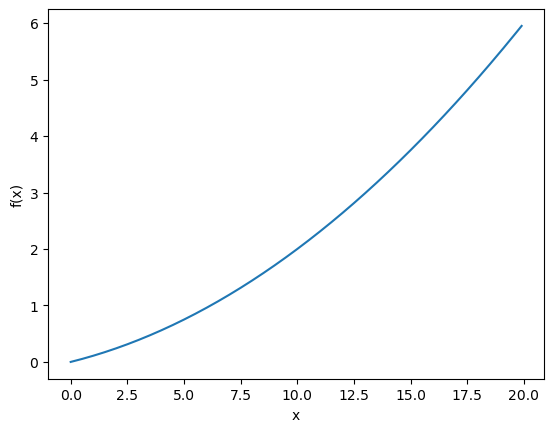

In [14]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0, 20, 0.1)
y = function_1(x)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.plot(x, y)
plt.show()

计算一下这个函数在x = 5和x = 10处的导数。

In [15]:
numerical_diff(function_1, 5)  # 0.1999999999990898
numerical_diff(function_1, 10) # 0.2999999999997449

0.2999999999997449

这里计算的导数是f(x)相对于x的变化量，对应函数的斜率。另外，$ y=0.01x^{2}+0.1x $的解析解是$\tfrac{\mathrm{d}f(x)}{\mathrm{d}x}=0.02x+0.1$。因此，在x = 5和x = 10处，“真的导数”分别为0.2和0.3。和上面的结果相比，我们发现虽然严格意义上它们并不一致，但误差非常小。实际上，误差小到基本上可以认为它们是相等的。<br>
现在，我们用上面的数值微分的值作为斜率，画一条直线。结果如图4-7所示，可以确认这些直线确实对应函数的切线（源代码在ch04/gradient_1d. py中）。

<img src="data/neural_study/image6.png" style="width:50%;">

##### 偏导数
接下来，我们看一下式(4.6)表示的函数。虽然它只是一个计算参数的平方和的简单函数，但是请注意和上例不同的是，这里有两个变量。

$f \left( x_{0},x_{1} \right)=x_{0}^{2}+x_{1}^{2} \qquad\qquad\qquad\qquad\qquad\left( 4.6 \right)$

In [16]:
def function_2(x):
    return x[0] ** 2 + x[1] ** 2
    # 或者return np.sum(x**2)

这里，我们假定向参数输入了一个NumPy数组。函数的内部实现比较简单，先计算NumPy数组中各个元素的平方，再求它们的和（np.sum(x**2)也可以实现同样的处理）。我们来画一下这个函数的图像。结果如图4-8所示，是一个三维图像。

<img src="data/neural_study/image7.png" style="width:50%;">

现在我们来求式（4.6）的导数。这里需要注意的是，式（4.6）有两个变量，所以有必要区分对哪个变量求导数，即对x0和x1两个变量中的哪一个求导数。另外，我们把这里讨论的有多个变量的函数的导数称为偏导数。用数学式表示的话，可以写成 $\frac{\partial f}{\partial x_0}\mathrm{、}\frac{\partial f}{\partial x_1}$

问题1：求x0 = 3,x1 = 4时，关于x0的偏导数 $\frac{\partial f}{\partial x_0}$
。


In [17]:
def function_tmp1(x0):
    return x0 * x0 + 4.0 ** 2
numerical_diff(function_tmp1, 3.0)

6.00000000000378

问题2：求x0 = 3,x1 = 4时，关于x1的偏导数 。$ \frac{\partial f}{\partial x_1}$

In [18]:
def function_tmp2(x1):
    return 3.0 ** 2 + x1 * x1
numerical_diff(function_tmp2, 4.0)

7.999999999999119

在这些问题中，我们定义了一个只有一个变量的函数，并对这个函数进 行了求导。例如，问题1中，我们定义了一个固定x1 = 4的新函数，然后对 只有变量x0的函数应用了求数值微分的函数。从上面的计算结果可知，问题 1的答案是6.00000000000378，问题2的答案是7.999999999999119，和解析 解的导数基本一致。<br>
像这样，偏导数和单变量的导数一样，都是求某个地方的斜率。不过， 偏导数需要将多个变量中的某一个变量定为目标变量，并将其他变量固定为 某个值。在上例的代码中，为了将目标变量以外的变量固定到某些特定的值 上，我们定义了新函数。然后，对新定义的函数应用了之前的求数值微分的 函数，得到偏导数。

#### 梯度
##### 介绍
在刚才的例子中，我们按变量分别计算了 x0 和 x1 的偏导数。现在，我们希望一起计算 x0 和 x1 的偏导数。比如，我们来考虑求x0 = 3,x1 = 4时(x0, x1)的偏导数 $(\frac{\partial f}{\partial x_0}\mathrm{,}\frac{\partial f}{\partial x_1})$。另外，像 $(\frac{\partial f}{\partial x_0}\mathrm{,}\frac{\partial f}{\partial x_1})$ 这样的由全部变量的偏导数汇总而成的向量称为梯度（gradient）。梯度可以像下面这样来实现。

In [21]:
def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x)

    for idx in range(x.size):
        tmp_val = x[idx]
        # f(x + h)的运算
        x[idx] = tmp_val + h
        fxh1 = f(x)

        # f(x - h)的运算
        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / 2 * h
        x[idx] = tmp_val # 还原值

    return grad

numerical_gradient(function_2, np.array([3.0, 4.0]))
numerical_gradient(function_2, np.array([0.0, 2.0]))
numerical_gradient(function_2, np.array([3.0, 0.0]))

array([6.e-08, 0.e+00])

函数numerical_gradient(f, x)的执行的处理和求单变量的数值微分基本没有区别。需要补充说明一下的是，np.zeros_ like(x)会生成一个形状和x相同、所有元素都为0的数组。<br> 
函数numerical_gradient(f, x)中，参数f为函数，x为NumPy数组，该函数对NumPy数组x的各个元素求数值微分。

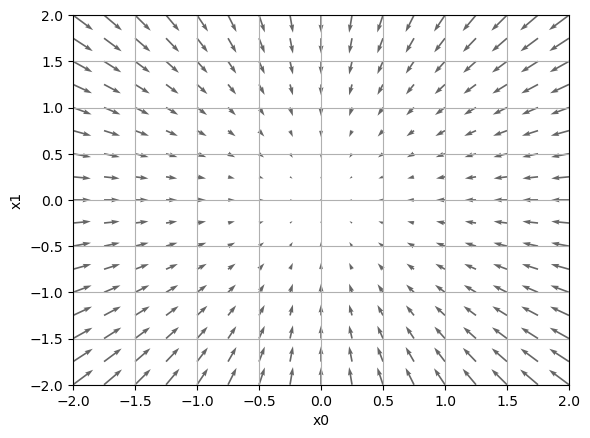

In [22]:
# coding: utf-8
# cf.http://d.hatena.ne.jp/white_wheels/20100327/p3
import numpy as np
import matplotlib.pylab as plt
from mpl_toolkits.mplot3d import Axes3D


def _numerical_gradient_no_batch(f, x):
    h = 1e-4  # 0.0001
    grad = np.zeros_like(x)
    
    for idx in range(x.size):
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        fxh1 = f(x)  # f(x+h)
        
        x[idx] = tmp_val - h 
        fxh2 = f(x)  # f(x-h)
        grad[idx] = (fxh1 - fxh2) / (2*h)
        
        x[idx] = tmp_val  # 値を元に戻す
        
    return grad


def numerical_gradient(f, X):
    if X.ndim == 1:
        return _numerical_gradient_no_batch(f, X)
    else:
        grad = np.zeros_like(X)
        
        for idx, x in enumerate(X):
            grad[idx] = _numerical_gradient_no_batch(f, x)
        
        return grad


def function_2(x):
    if x.ndim == 1:
        return np.sum(x**2)
    else:
        return np.sum(x**2, axis=1)


def tangent_line(f, x):
    d = numerical_gradient(f, x)
    print(d)
    y = f(x) - d*x
    return lambda t: d*t + y


if __name__ == '__main__':
    x0 = np.arange(-2, 2.5, 0.25)
    x1 = np.arange(-2, 2.5, 0.25)
    X, Y = np.meshgrid(x0, x1)
    
    X = X.flatten()
    Y = Y.flatten()

    grad = numerical_gradient(function_2, np.array([X, Y]).T).T

    plt.figure()
    plt.quiver(X, Y, -grad[0], -grad[1],  angles="xy",color="#666666")
    plt.xlim([-2, 2])
    plt.ylim([-2, 2])
    plt.xlabel('x0')
    plt.ylabel('x1')
    plt.grid()
    plt.draw()
    plt.show()

像这样，我们可以计算(x0 ,x1)在各点处的梯度。上例中，点(3, 4)处的梯度是(6, 8)、点(0, 2)处的梯度是(0, 4)、点(3, 0)处的梯度是(6, 0)。这个梯度意味着什么呢？为了更好地理解，我们把 $f \left( x_{0},x_{1} \right)=x_{0}^{2}+x_{1}^{2} $ 的梯度画在图上。不过，这里我们画的是元素值为负梯度 B 的向量。<br>
如图4-9所示，$f \left( x_{0},x_{1} \right)=x_{0}^{2}+x_{1}^{2} $ 的梯度呈现为有向向量（箭头）。观察图4-9，我们发现梯度指向函数f(x0,x1)的“最低处”（最小值），就像指南针一样，所有的箭头都指向同一点。其次，我们发现离“最低处”越远，箭头越大。<br>
虽然图4-9中的梯度指向了最低处，但并非任何时候都这样。实际上，**梯度会指向各点处的函数值降低的方向**。更严格地讲，梯度指示的方向是各点处的函数值**减小最多的方向A**。这是一个非常重要的性质，请一定 牢记！

##### 梯度法
机器学习的主要任务是在学习时寻找最优参数。同样地，神经网络也必须在学习时找到**最优参数（权重和偏置）**。这里所说的最优参数是指**损失函数取最小值时的参数**。但是，一般而言，损失函数很复杂，参数空间庞大，我们不知道它在何处能取得最小值。而通过巧妙地**使用梯度来寻找函数最小值** （或者尽可能小的值）的方法就是梯度法。<br>
这里需要注意的是，梯度表示的是各点处的函数值减小最多的方向。因此，无法保证梯度所指的方向就是函数的最小值或者真正应该前进的方向。实际上，在复杂的函数中，**梯度指示的方向基本上都不是函数值最小处**。
> 函数的极小值、最小值以及被称为**鞍点（saddle point）**的地方，梯度为0。极小值是局部最小值，也就是限定在某个范围内的最小值。鞍点是从某个方向上看是极大值，从另一个方向上看则是极小值的点。虽然**梯度法是要寻找梯度为0的地方，但是那个地方不一定就是最小值（也有可能是极小值或者鞍点）**。此外，当函数很复杂且呈扁平状时，学习可能会进入一个（几乎）平坦的地区， 陷入被称为**“学习高原”**的无法前进的停滞期。

虽然梯度的方向并不一定指向最小值，但**沿着它的方向能够最大限度地减小函数的值**。因此，在寻找函数的最小值（或者尽可能小的值）的位置的任务中，要以梯度的信息为线索，决定前进的方向。<br>
此时梯度法就派上用场了。在梯度法中，函数的取值**从当前位置沿着梯度方向前进一定距离，然后在新的地方重新求梯度，再沿着新梯度方向前进**，如此反复，不断地沿梯度方向前进。像这样，通过不断地沿梯度方向前进，逐渐减小函数值的过程就是梯度法（gradient method）。梯度法是解决机器学习中**最优化问题的常用方法**，特别是在神经网络的学习中经常被使用。<br>
> 根据目的是寻找最小值还是最大值，梯度法的叫法有所不同。严格地讲，寻找最小值的梯度法称为梯度下降法（gradient descent method），寻找最大值的梯度法称为梯度上升法（gradient ascent method）。但是**通过反转损失函数的符号**，求最小值的问题和求最大值的问题会变成相同的问题，因此“下降”还是“上升”的差异本质上并不重要。一般来说，神经网络（深度学习）中，梯度法主要是**指梯度下降法。**

现在，我们尝试用数学式来表示梯度法，如式（4.7）所示。

$\begin{aligned} & x_{0}=x_0-\eta\frac{\partial f}{\partial x_0} \\ & & (4.7) \\ & x_{1}=x_1-\eta\frac{\partial f}{\partial x_1} \end{aligned}$

式（4.7）的 η 表示更新量，在神经网络的学习中，称为**学习率（learning rate）**。学习率决定在一次学习中，应该学习多少，以及在多大程度上更新参数。<br>
式（4.7）是表示更新一次的式子，这个步骤会反复执行。也就是说，每一步都按式（4.7）更新变量的值，通过反复执行此步骤，逐渐减小函数值。虽然这里只展示了有两个变量时的更新过程，但是即便增加变量的数量，也可以通过类似的式子（各个变量的偏导数）进行更新。<br>
学习率需要事先确定为某个值，比如0.01或0.001。一般而言，这个值过大或过小，都无法抵达一个“好的位置”。在神经网络的学习中，一般会 **一边改变学习率的值，一边确认学习**是否正确进行了。<br>
下面，我们用Python来实现梯度下降法。如下所示，这个实现很简单。

In [40]:
def gradient_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x

    for i in range(step_num):
        grad = numerical_gradient(f, x)
        x -= lr * grad

    return x

参数f是要进行最优化的函数，init_x是初始值，lr是学习率learning rate，step_num是梯度法的重复次数。numerical_gradient(f,x)会求函数的梯度，用该梯度乘以学习率得到的值进行更新操作，由step_num指定重复的次数。<br>
使用这个函数可以求函数的极小值，顺利的话，还可以求函数的最小值。下面，我们就来尝试解决下面这个问题。

问题：请用梯度法求 $f \left( x_{0},x_{1} \right)=x_{0}^{2}+x_{1}^{2} $ 的最小值。

In [41]:
def function_2(x):
    return x[0]**2 + x[1]**2

init_x = np.array([-3.0, 4.0])
gradient_descent(function_2, init_x=init_x, lr=0.1, step_num=100)

array([-6.11110793e-10,  8.14814391e-10])

In [42]:
# # coding: utf-8
# import numpy as np
# import matplotlib.pylab as plt

# def gradient_descent(f, init_x, lr=0.01, step_num=100):
#     x = init_x
#     x_history = []

#     for i in range(step_num):
#         x_history.append( x.copy() )

#         grad = numerical_gradient(f, x)
#         x -= lr * grad

#     return x, np.array(x_history)


# def function_2(x):
#     return x[0]**2 + x[1]**2

# init_x = np.array([-3.0, 4.0])    

# lr = 0.1
# step_num = 20
# x, x_history = gradient_descent(function_2, init_x, lr=lr, step_num=step_num)

# plt.plot( [-5, 5], [0,0], '--b')
# plt.plot( [0,0], [-5, 5], '--b')
# plt.plot(x_history[:,0], x_history[:,1], 'o')

# plt.xlim(-3.5, 3.5)
# plt.ylim(-4.5, 4.5)
# plt.xlabel("X0")
# plt.ylabel("X1")
# plt.show()

这里，设初始值为(-3.0, 4.0)，开始使用梯度法寻找最小值。最终的结果是(-6.1e-10, 8.1e-10)，非常接近(0，0)。实际上，真的最小值就是(0，0)，所以说通过梯度法我们基本得到了正确结果。如果用图来表示梯度法的更新过程，则如图4-10所示。可以发现，原点处是最低的地方，函数的取值一点点在向其靠近。

##### 学习率大小
前面说过，学习率过大或者过小都无法得到好的结果。我们来做个实验验证一下。

In [43]:
init_x = np.array([-3.0, 4.0])
gradient_descent(function_2, init_x=init_x, lr=10, step_num=100)

init_x = np.array([-3.0, 4.0])
gradient_descent(function_2, init_x=init_x, lr=1e-10, step_num=100)

array([-2.99999994,  3.99999992])

实验结果表明，学习率过大的话，会发散成一个很大的值；反过来，学 习率过小的话，基本上没怎么更新就结束了。也就是说，设定合适的学习率 是一个很重要的问题<br>
> 像**学习率这样的参数称为超参数**。这是一种和神经网络的参数（权重和偏置）性质不同的参数。相对于神经网络的权重参数是通过训练 数据和学习算法自动获得的，**学习率这样的超参数则是人工设定的**。一般来说，超参数**需要尝试多个值**，以便找到一种可以使学习顺利进行的设定。

##### 神经网络的梯度
神经网络的学习也要求梯度。这里所说的梯度是指**损失函数关于权重参数的梯度**。比如，有一个只有一个形状为2 × 3的权重W的神经网络，损失函数用L表示。此时，梯度可以用表示 $\frac{\partial L}{\partial\boldsymbol{W}} $。用数学式表示的话，如下所示。

$\begin{aligned} \boldsymbol{W} & = \begin{pmatrix} w_{11} & w_{12} & w_{13} \\ w_{21} & w_{22} & w_{23} \end{pmatrix} \\ & & \mathrm{(4.8)} \\ \begin{aligned} \frac{\partial L}{\partial\boldsymbol{W}} \end{aligned} & = \begin{pmatrix} \frac{\partial L}{\partial w_{11}} & \frac{\partial L}{\partial w_{12}} & \frac{\partial L}{\partial w_{13}} \\ \frac{\partial L}{\partial w_{21}} & \frac{\partial L}{\partial w_{22}} & \frac{\partial L}{\partial w_{23}} \end{pmatrix} \end{aligned}$

$\frac{\partial L}{\partial\boldsymbol{W}} $ 的元素由各个元素关于W的偏导数构成。比如，第1行第1列的元素 $\frac{\partial L}{\partial w_{11}}$ 表**示当 w11 稍微变化时，损失函数L会发生多大变化**。这里的重点是，$\frac{\partial L}{\partial\boldsymbol{W}} $ 的形状和W相同。实际上，式（4.8）中的W和 $\frac{\partial L}{\partial\boldsymbol{W}} $  都是2 × 3的形状。

下面，我们以一个简单的神经网络为例，来实现求梯度的代码。为此，我们要实现一个名为simpleNet的类。

In [44]:
import numpy as np
from common.functions import softmax, cross_entropy_error
from common.gradient import numerical_gradient

class simpleNet:
    def __init__(self):
        self.W = np.random.randn(2,3) # 用高斯分布进行初始化

    def predict(self, x):
        return np.dot(x, self.W)
    
    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)
        loss = cross_entropy_error(y, t)

        return loss

这里使用了common/functions.py中的softmax和cross_entropy_error方 法，以及common/gradient.py中的numerical_gradient方法。simpleNet类只有一个实例变量，即形状为2×3的权重参数。它有两个方法，一个是用于预测的predict(x)，另一个是用于求损失函数值的loss(x,t)。这里参数x接收输入数据，t接收正确解标签。现在我们来试着用一下这个simpleNet。

In [75]:
net = simpleNet()
print(net.W) # 权重参数

x = np.array([0.6, 0.9])
p = net.predict(x)
print(p)

np.argmax(p) # 最大值的索引
t = np.array([0, 0, 1]) # 正确解标签
net.loss(x, t)

[[-0.56401763  0.83119061  1.22657228]
 [ 0.58920119  0.77989179  0.59385635]]
[0.19187049 1.20061697 1.27041408]


np.float64(0.8209566596032419)

接下来求梯度。和前面一样，我们使用numerical_gradient(f, x)求梯度（这里定义的函数f(W)的参数W是一个伪参数。因为numerical_gradient(f, x)会在内部执行f(x),为了与之兼容而定义了f(W)）。

In [78]:
def f(W):
    return net.loss(x, t)

dW = numerical_gradient(f, net.W)
print(dW)

[[ 0.08978599  0.24620769 -0.33599368]
 [ 0.13467899  0.36931153 -0.50399051]]


numerical_gradient(f, x)的参数f是函数，x是传给函数f的参数。因此，这里参数x取net.W，并定义一个计算损失函数的新函数f，然后把这个新定义的函数传递给numerical_gradient(f, x)。<br>
numerical_gradient(f, net.W)的结果是dW，一个形状为2 × 3的二维数组。观察一下dW的内容，例如，会发现 $\frac{\partial L}{\partial\boldsymbol{W}} $ 中的 $\frac{\partial L}{\partial w_{11}}$ 的值大约是0.2，这表示如果将 w11 增加h，那么损失函数的值会增加0.2h。再如，$\frac{\partial L}{\partial w_{23}}$ 对应的值大约 是−0.5，这表示如果将w23增加h，损失函数的值将减小0.5h。因此，从**减小损失函数值的观点来看，w23 应向正方向更新，w11 应向负方向更新**。至于更新的程度，w23 比 w11 的贡献要大。<br>
另外，在上面的代码中，定义新函数时使用了“def f(x):···”的形式。实际上，Python中如果定义的是简单的函数，可以使用lambda表示法。使 用lambda的情况下，上述代码可以如下实现。

In [ ]:
f = lambda W: net.loss(x, t)
dW = numerical_gradient(f, net.W)

求出神经网络的梯度后，接下来只需根据梯度法，更新权重参数即可。在下一节中，我们会以2层神经网络为例，实现整个学习过程。

> 为了对应形状为多维数组的权重参数W，这里使用的numerical_ gradient()和之前的实现稍有不同。不过，改动只是为了对应多维数组，所以改动并不大。这里省略了对代码的说明，细节在源代码（common/gradient.py）。